# MovieLens Linear Models Demo

This notebook demonstrates a clean, **deterministic** baseline for predicting movie average ratings using simple linear models:

- **Download** the MovieLens *ml-latest-small* dataset
- Build **movie-level features** (counts, years, one-hot genres)
- **Random train/validation/test** split (with a fixed seed)
- Train **Linear**, **Ridge** (α=0.1), **Lasso** (α=0.001) — *no grid search*
- **Interpret Coefficients** to understand feature effects
- **Time-based Train/Test Split** to show a more realistic scenario

> Tip: This is a *movie-level* demo. Real recommenders are user–movie level and benefit from collaborative features (user/movie factors).


## 0. Setup & Utilities


In [1]:
import os, io, zipfile, math, re, json, textwrap
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from datetime import datetime

np.set_printoptions(suppress=True)
pd.set_option("display.max_columns", 200)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def r2_rmse(y_true, y_pred):
    return r2_score(y_true, y_pred), rmse(y_true, y_pred)


## 1. Download MovieLens (ml-latest-small)
If files already exist locally, this step will skip the download.


In [2]:
import requests

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
ZIP_URL = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
ZIP_PATH = DATA_DIR / "ml-latest-small.zip"
EXTRACT_DIR = DATA_DIR / "ml-latest-small"

if not EXTRACT_DIR.exists():
    if not ZIP_PATH.exists():
        print("Downloading:", ZIP_URL)
        r = requests.get(ZIP_URL, timeout=60)
        r.raise_for_status()
        ZIP_PATH.write_bytes(r.content)
        print("Saved:", ZIP_PATH)

    print("Extracting:", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    print("Already available:", EXTRACT_DIR)

# Load CSVs
ratings = pd.read_csv(EXTRACT_DIR / "ratings.csv")
movies  = pd.read_csv(EXTRACT_DIR / "movies.csv")

print("ratings:", ratings.shape, "| movies:", movies.shape)
display(ratings.head())
display(movies.head())


Already available: data\ml-latest-small
ratings: (100836, 4) | movies: (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Build Movie-Level Features

We aggregate **ratings** per `movieId` to compute:
- `avg_rating` : mean rating
- `n_ratings` : number of ratings
- `first_year`, `last_year` : min/max rating year (from timestamps)
- `rating_span` : last_year - first_year


We also one-hot encode the **genres** from `movies.csv`.


In [3]:
# Convert timestamps to years for first/last rating year
ratings["year"] = pd.to_datetime(ratings["timestamp"], unit="s").dt.year

agg = ratings.groupby("movieId").agg(
    avg_rating=("rating", "mean"),
    n_ratings=("rating", "size"),
    first_year=("year", "min"),
    last_year=("year", "max"),
).reset_index()

# add a feature for the rating span (last_year - first_year)
agg["rating_span"] = agg["last_year"] - agg["first_year"]

# Genres one-hot
def split_genres(g):
    if pd.isna(g) or g == "(no genres listed)":
        return []
    return g.split("|")

genre_sets = movies["genres"].apply(split_genres)
unique_genres = sorted(set(g for s in genre_sets for g in s))
# Remove empty label if present
unique_genres = [g for g in unique_genres if g and g != "(no genres listed)"]

genre_mat = {f"genre_{g}": [] for g in unique_genres}
for gs in genre_sets:
    gs_set = set(gs)
    for g in unique_genres:
        genre_mat[f"genre_{g}"].append(g in gs_set)

genre_df = pd.DataFrame(genre_mat)
movies_expanded = pd.concat([movies[["movieId", "title"]], genre_df], axis=1)

# Merge features
movie_features = agg.merge(movies_expanded, on="movieId", how="left")

# Optional: extract release year from title "(YYYY)"
def extract_release_year(title):
    m = re.search(r"\((\d{4})\)", str(title))
    return int(m.group(1)) if m else np.nan

movie_features["release_year"] = movie_features["title"].apply(extract_release_year)

display(movie_features.head())
print(movie_features.shape)


,movieId,avg_rating,n_ratings,first_year,last_year,rating_span,title,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,release_year
0,1,3.920930,215,1996,2018,22,Toy Story (1995),False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,1995.0
1,2,3.431818,110,1996,2018,22,Jumanji (1995),False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,1995.0
2,3,3.259615,52,1996,2017,21,Grumpier Old Men (1995),False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1995.0
3,4,2.357143,7,1996,2009,13,Waiting to Exhale (1995),False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,1995.0
4,5,3.071429,49,1996,2018,22,Father of the Bride Part II (1995),False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1995.0


(9724, 27)


## 3. Feature Matrix (X) and Target (y)

We use numeric predictors:
- `n_ratings_log1p` (log-transformed count)    &nbsp; &nbsp; &nbsp; Why is this useful? &nbsp; &nbsp;  find out!
- `first_year`
- `last_year`
- `rating_span`

…and all one-hot `genre_*` columns.

Target: **`avg_rating`**.


In [4]:
target_col = "avg_rating"
num_cols = ["n_ratings", "first_year", "last_year", "rating_span"]
genre_cols = [c for c in movie_features.columns if c.startswith("genre_")]

X = movie_features[num_cols + genre_cols].copy()
X["n_ratings_log1p"] = np.log1p(X["n_ratings"])
feature_cols = ["n_ratings_log1p", "first_year", "last_year", "rating_span"] + genre_cols
X = X[feature_cols]
y = movie_features[target_col].copy()

print("X shape:", X.shape, "| y shape:", y.shape)
display(X.head())


X shape: (9724, 23) | y shape: (9724,)


,n_ratings_log1p,first_year,last_year,rating_span,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Fantasy,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,5.375278,1996,2018,22,False,True,True,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,4.709530,1996,2018,22,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,3.970292,1996,2017,21,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,2.079442,1996,2009,13,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False
4,3.912023,1996,2018,22,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## 4. Random Train /  Test Split

- Random `train/test` split (80/20).
- Train **Linear**, **Ridge (α=0.1)**, **Lasso (α=0.001)** — fixed alphas for a simple, reproducible baseline.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np, pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree

# --- split only into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=None
)  # note: to use the same split, set the same random_state!

# --- columns: scale numeric only; passthrough genre_* ---
num_cols = ["n_ratings_log1p", "first_year", "last_year", "rating_span"]
cat_cols = [c for c in X.columns if c.startswith("genre_")]


pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),  # scale numeric
        ("cat", "passthrough", cat_cols),     # keep booleans as-is
    ],
    remainder="drop"
)

# --- fixed alphas ---
RIDGE_ALPHA = 0.1
LASSO_ALPHA = 0.001

# --- build pipelines & fit on TRAIN ---
lin_full   = Pipeline([("pre", pre), ("model", LinearRegression())]).fit(X_train, y_train)
ridge_full = Pipeline([("pre", pre), ("model", Ridge(alpha=RIDGE_ALPHA))]).fit(X_train, y_train)
lasso_full = Pipeline([("pre", pre), ("model", Lasso(alpha=LASSO_ALPHA, max_iter=20000))]).fit(X_train, y_train)

# no need to normalize for trees, but it will not hurt either.
# It is used here just because we want to reuse the same preprocessor for all models.
# The max_depth=6 is a simple regularization to prevent overfitting on this dataset.
tree_full  = Pipeline([("pre", pre), ("model", DecisionTreeRegressor(random_state=42,max_depth=6))]).fit(X_train, y_train)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))



def metrics_row(pipe, Xtrain, ytrain, Xtest, ytest):
    ytrain_p = pipe.predict(Xtrain)
    ytest_p = pipe.predict(Xtest)
    return {
        "R2_train": r2_score(ytrain, ytrain_p),
        "RMSE_train": rmse(ytrain, ytrain_p),
        "R2_test": r2_score(ytest, ytest_p),
        "RMSE_test": rmse(ytest, ytest_p),
    }

# --- build “sweep-style” single-row tables (train/test only) ---
linear_m = metrics_row(lin_full, X_train, y_train, X_test, y_test)
linear_table = pd.DataFrame([{"Alpha": None, **linear_m}])  # ** unpack dict into row

ridge_m = metrics_row(ridge_full, X_train, y_train, X_test, y_test)
ridge_table = pd.DataFrame([{"Alpha": RIDGE_ALPHA, **ridge_m}])  

lasso_m = metrics_row(lasso_full, X_train, y_train, X_test, y_test)
lasso_table = pd.DataFrame([{"Alpha": LASSO_ALPHA, **lasso_m}])

tree_m = metrics_row(tree_full, X_train, y_train, X_test, y_test)
tree_table = pd.DataFrame([{"Alpha": None, **tree_m}])

# --- summary table (test only) ---
lin_m = metrics_row(lin_full, X_train, y_train, X_test, y_test)
summary = pd.DataFrame([
    {"Model": "Linear",                   "Alpha": None,
     "R2_test": lin_m["R2_test"],   "RMSE_test": lin_m["RMSE_test"]},
    {"Model": f"Ridge (α={RIDGE_ALPHA})", "Alpha": RIDGE_ALPHA,
     "R2_test": ridge_m["R2_test"], "RMSE_test": ridge_m["RMSE_test"]},
    {"Model": f"Lasso (α={LASSO_ALPHA})", "Alpha": LASSO_ALPHA,
     "R2_test": lasso_m["R2_test"], "RMSE_test": lasso_m["RMSE_test"]},
    {"Model": "Regression Tree", "Alpha": None,
     "R2_test": tree_m["R2_test"],  "RMSE_test": tree_m["RMSE_test"]},
])

print("— Linear Regression —")
display(linear_table.round(4))
print("— Ridge alpha sweep —")
display(ridge_table.round(4))
print("— Lasso alpha sweep —")
display(lasso_table.round(4))
print("— Regression Tree —")
display(tree_table.round(4))

print("— Summary (Test) —")
display(summary.sort_values("RMSE_test").round(4))




— Linear Regression —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,None,0.1218,0.8218,0.1185,0.8007


— Ridge alpha sweep —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,0.1,0.1218,0.8218,0.1185,0.8007


— Lasso alpha sweep —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,0.001,0.1213,0.8221,0.1187,0.8006


— Regression Tree —


,Alpha,R2_train,RMSE_train,R2_test,RMSE_test
0,None,0.1527,0.8073,0.1116,0.8038


— Summary (Test) —


,Model,Alpha,R2_test,RMSE_test
2,Lasso (α=0.001),0.001,0.1187,0.8006
0,Linear,NaN,0.1185,0.8007
1,Ridge (α=0.1),0.100,0.1185,0.8007
3,Regression Tree,NaN,0.1116,0.8038


<div style="background-color: black; padding: 20px;">
<b>Question:</b> <br>
Can the test RMSE be smaller than the train RMSE? <br>
&nbsp; &nbsp; Look at the documentation of DecisionTreeRegressor, or find elsewhere. <br>
 
There may be several reasons for such a phenomenon:<br>

 1. Random variation in the train/test split, especially with a small dataset. <br>
    To check this, we can try different random seeds for the train/test split and see if the pattern holds.<br>

 2. The test set may by chance be easier to predict than the training set, leading to a lower test RMSE.<br>
    To check this, we can inspect the distribution of the target variable in both sets and see if the test set is indeed easier.<br>
    Different random seed may overcome this issue.<br>

 3. In regularization, it can happen that the regularized model has smaller RMSE on the test  <br>
    than on training because the regularization is not applied to the test set.<br>

 4. Other things that can cause this in general:<br>
    - data leakage from train to test.<br>
    - underfitting. the model is too simple. Again, to check try a different random seed.<br>
 
 in general it is better to use cross-validation to get a more reliable estimate of the test performance,<br>
  especially with small datasets. Try it!<br>
 
 also, compare the behaviour of the tree regressor with the linear models in terms of train/test performance and overfitting.
</div>


<div style="background-color: black; padding: 20px;">
<b>Question:</b> <br>
Was the test set normalized? <br>
Do we need to take care of it?
<div>

In [6]:
# The ColumnTransformer and Pipeline handle this automatically.
# When you call `fit` on the training data, the scaler learns the mean and standard deviation.
# When you call `predict` on the test data, the scaler uses the same mean and standard deviation to transform the test data.

# to demonatrate this, we get from the lin_full pipeline the values of the transformation that the
# standard scaler found on the train set, and print it:
scaler = lin_full.named_steps["pre"].named_transformers_["num"]
print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)
print()

# now apply the same transformation to the test set and print the first 5 rows:
X_test_scaled = scaler.transform(X_test[num_cols])

# show mean and std of each feature for the original test set and the scaled test set:
print("Mean of original test set:")
print(X_test[num_cols].mean())
print()
print("Std of original test set:")
print(X_test[num_cols].std())
print()
print("Mean of scaled test set:") # should be close to 0 for all features
print(X_test_scaled.mean(axis=0))   
print()
print("Std of scaled test set:") # should be close to 1 for all features
print(X_test_scaled.std(axis=0))   
print()

# no need to normalize for trees, but it will not hurt either.
# It is used here just because we want to reuse the same preprocessor for all models.

Mean: [   1.65202398 2006.83235381 2013.41243021    6.5800764 ]
Scale: [1.07325752 7.14303011 5.79497523 7.35266547]

Mean of original test set:
n_ratings_log1p       1.651099
first_year         2006.816998
last_year          2013.375600
rating_span           6.558602
dtype: float64

Std of original test set:
n_ratings_log1p    1.076215
first_year         7.129737
last_year          5.750269
rating_span        7.334448
dtype: float64

Mean of scaled test set:
[-0.00086171 -0.00214977 -0.00635559 -0.00292066]

Std of scaled test set:
[1.0025837  0.99796789 0.99211533 0.99735142]



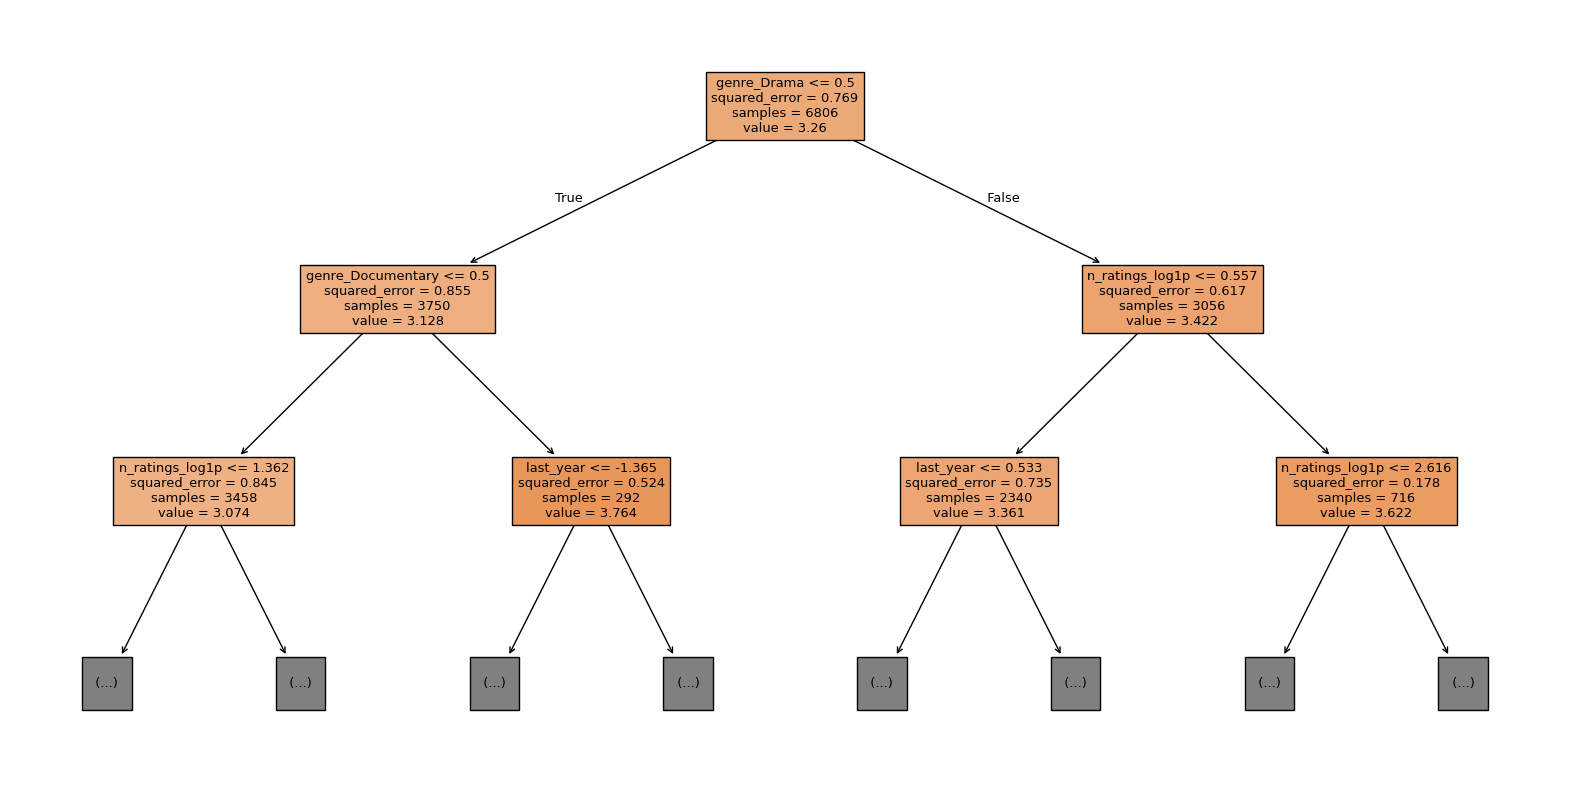

In [7]:
# show the tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree_full.named_steps["model"], feature_names=feature_cols, filled=True, max_depth=2)
plt.show()

<div style="background-color: black; padding: 20px;">
<b>Question:</b> <br>
1. How does the tree regressor predict? <br>
&nbsp; &nbsp; Look at the documentation of DecisionTreeRegressor, or find elsewhere. <br>
2. How tree maximum depth affects the granularity of prediction?
</div>

## 5. Interpret Coefficients

Coefficient magnitudes reflect feature influence **under the model’s assumptions**.
For linear models with mixed-scale features, magnitudes are not directly comparable unless features are standardized.
Here, numeric features have different scales than booleans (`genre_*`), so compare directions and relative sizes with care.

> For demos, it’s common to standardize numeric features before Ridge/Lasso.


In [8]:
def coef_df(pipeline, cols):
    # For pipelines, we need to access the model inside the pipeline
    if hasattr(pipeline, 'named_steps'):
        # It's a pipeline - get the model from the 'model' step
        model = pipeline.named_steps['model']
    else:
        # It's a direct model
        model = pipeline
    
    coef = getattr(model, "coef_", None)
    if coef is None:
        return pd.DataFrame({"feature": cols, "coef": np.nan})
    return pd.DataFrame({"feature": cols, "coef": coef}).sort_values("coef", ascending=False)

cols = X.columns.tolist()

print("Top positive coefficients (Linear):")
display(coef_df(lin_full, cols).head(10))

print("Top negative coefficients (Linear):")
display(coef_df(lin_full, cols).tail(10))


Top positive coefficients (Linear):


,feature,coef
10,genre_Documentary,0.617812
6,genre_Animation,0.448735
13,genre_Film-Noir,0.288840
0,n_ratings_log1p,0.269978
11,genre_Drama,0.254708
21,genre_War,0.223386
22,genre_Western,0.163454
18,genre_Romance,0.092508
17,genre_Mystery,0.081645
9,genre_Crime,0.080016


Top negative coefficients (Linear):


,feature,coef
5,genre_Adventure,-0.003290
2,last_year,-0.033864
16,genre_Musical,-0.047689
8,genre_Comedy,-0.082104
19,genre_Sci-Fi,-0.087115
3,rating_span,-0.101244
20,genre_Thriller,-0.107300
14,genre_Horror,-0.207295
4,genre_Action,-0.212489
7,genre_Children,-0.325079


In [9]:
# show the tree best features
tree_model = tree_full.named_steps["model"]
feature_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": tree_model.feature_importances_
}).sort_values("importance", ascending=False)
print("Top features by importance (Tree):")
display(feature_importances.head(10))

Top features by importance (Tree):


,feature,importance
11,genre_Drama,0.182005
0,n_ratings_log1p,0.172242
10,genre_Documentary,0.160504
1,first_year,0.128395
2,last_year,0.071203
4,genre_Action,0.070714
6,genre_Animation,0.052193
8,genre_Comedy,0.045291
20,genre_Thriller,0.021820
7,genre_Children,0.021106


In [10]:
# Get the model from the pipeline
linear_model = lin_full.named_steps['model']
intercept = linear_model.intercept_
coefficients = linear_model.coef_

# Create the formula string
formula_parts = [f"{intercept:.4f}"]  # Start with intercept

for i, (feature, coef) in enumerate(zip(cols, coefficients)):
    if coef != 0:  # Only include non-zero coefficients
        sign = "+" if coef >= 0 else ""
        formula_parts.append(f"{sign}{coef:.4f} * {feature}")

formula = " + ".join(formula_parts)
print("Linear Regression Formula:")
print(f"avg_rating = {formula}")



Linear Regression Formula:
avg_rating = 3.1898 + +0.2700 * n_ratings_log1p + +0.0767 * first_year + -0.0339 * last_year + -0.1012 * rating_span + -0.2125 * genre_Action + -0.0033 * genre_Adventure + +0.4487 * genre_Animation + -0.3251 * genre_Children + -0.0821 * genre_Comedy + +0.0800 * genre_Crime + +0.6178 * genre_Documentary + +0.2547 * genre_Drama + +0.0291 * genre_Fantasy + +0.2888 * genre_Film-Noir + -0.2073 * genre_Horror + +0.0030 * genre_IMAX + -0.0477 * genre_Musical + +0.0816 * genre_Mystery + +0.0925 * genre_Romance + -0.0871 * genre_Sci-Fi + -0.1073 * genre_Thriller + +0.2234 * genre_War + +0.1635 * genre_Western


## 6. Time-based Train/Test Split

Instead of a random split, we split by **first rating year** (`first_year`) to simulate training on *earlier* movies and testing on *later* ones.
We'll pick a cutoff year as the **80th percentile** of `first_year` (you can change this).

> Note: because `avg_rating` aggregates *all* ratings, there is some leakage from post-cutoff ratings into the target. For a truly time-causal setup, compute targets from **pre-cutoff ratings only**; that’s more involved, so we keep it simple here for demonstration.


In [11]:
# Choose cutoff as 80th percentile of first_year among movies with complete features
mask_complete = (~movie_features["first_year"].isna())
cutoff = int(movie_features.loc[mask_complete, "first_year"].quantile(0.8))
cutoff


2015

In [12]:
# Time-based split
mask_train_time = movie_features["first_year"] <= cutoff
mask_test_time  = movie_features["first_year"]  > cutoff

X_train_time = X.loc[mask_train_time].copy()
y_train_time = y.loc[mask_train_time].copy()
X_test_time  = X.loc[mask_test_time].copy()
y_test_time  = y.loc[mask_test_time].copy()

print("Cutoff year:", cutoff)
print("Train_time:", X_train_time.shape, "| Test_time:", X_test_time.shape)

# Fit fixed-alpha models
lin_t   = LinearRegression().fit(X_train_time, y_train_time)
ridge_t = Ridge(alpha=0.1).fit(X_train_time, y_train_time)
lasso_t = Lasso(alpha=0.001, max_iter=20000).fit(X_train_time, y_train_time)

# Evaluate
def eval_row(name, model, Xtr, ytr, Xte, yte):
    ytr_p = model.predict(Xtr)
    yte_p = model.predict(Xte)
    return {
        "Model": name,
        "Train RMSE": rmse(ytr, ytr_p),
        "Train R2": r2_score(ytr, ytr_p),
        "Test RMSE": rmse(yte, yte_p),
        "Test R2": r2_score(yte, yte_p),
    }

rows_time = [
    eval_row("Linear (time)", lin_t, X_train_time, y_train_time, X_test_time, y_test_time),
    eval_row("Ridge α=0.1 (time)", ridge_t, X_train_time, y_train_time, X_test_time, y_test_time),
    eval_row("Lasso α=0.001 (time)", lasso_t, X_train_time, y_train_time, X_test_time, y_test_time),
]
pd.DataFrame(rows_time).round(4)


Cutoff year: 2015
Train_time: (7789, 23) | Test_time: (1935, 23)


,Model,Train RMSE,Train R2,Test RMSE,Test R2
0,Linear (time),0.7224,0.1686,1.1236,0.0079
1,Ridge α=0.1 (time),0.7224,0.1686,1.1236,0.0079
2,Lasso α=0.001 (time),0.7226,0.1680,1.1236,0.0079


In [13]:
# apply a treeregressor to the same data
from sklearn.tree import DecisionTreeRegressor
tree_t = DecisionTreeRegressor(random_state=42, max_depth=5).fit(X_train_time, y_train_time)
eval_row("Decision Tree (time)", tree_t, X_train_time, y_train_time, X_test_time, y_test_time)


{'Model': 'Decision Tree (time)',
 'Train RMSE': 0.7261661046398786,
 'Train R2': 0.15982871802121035,
 'Test RMSE': 1.1289917061214196,
 'Test R2': -0.0016868339853042258}

Other things to check:
Are some of the features correlated? does it harm our models?

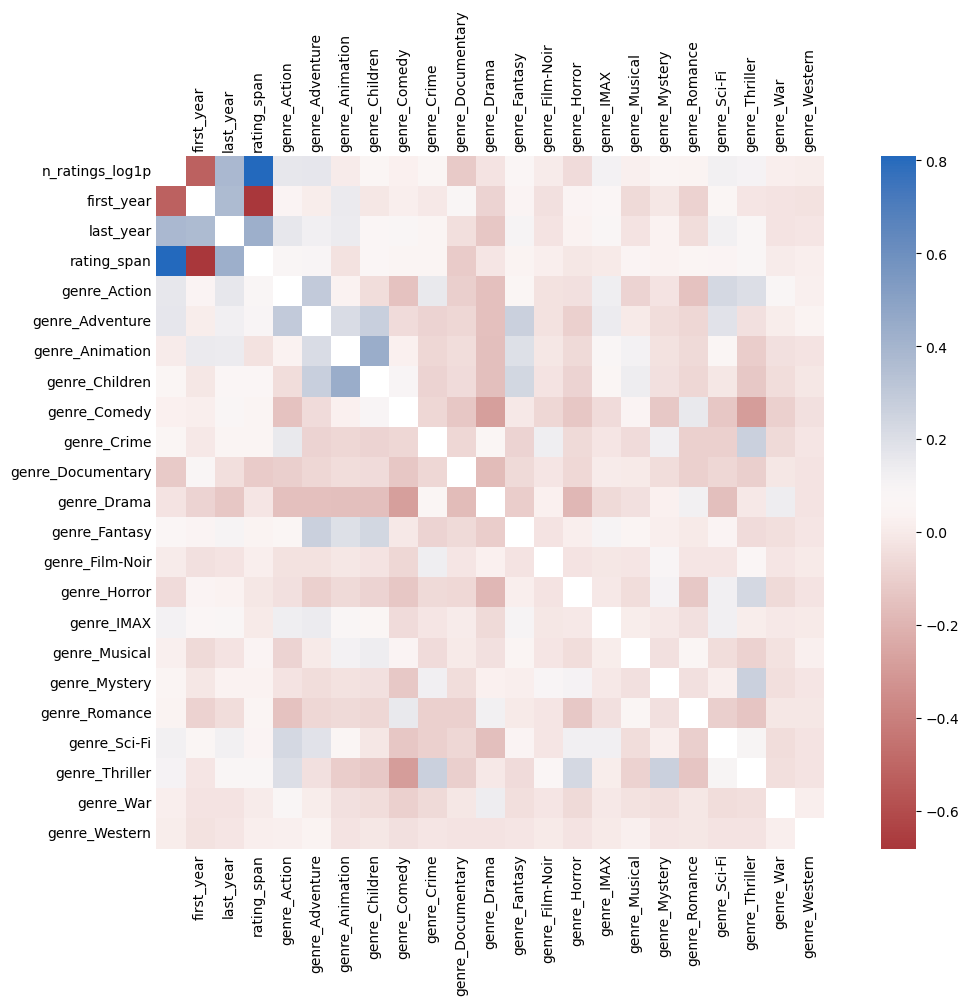

In [14]:
# Are some of the features correlated? does it harm our models?
# How can we check it?
import seaborn as sns
import matplotlib.pyplot as plt

# lets see how each feature correlates to the others.


# first transform all non numeric features to numeric (the genres)
# this may not be useful, but let's see what we get.
X_corr = X.copy()
for c in X_corr.columns:
    if X_corr[c].dtype == "bool":
        X_corr[c] = X_corr[c].astype(int)   
corr_matrix = X_corr.corr()

# remove the diagonal elements (correlation of a feature with itself) to make the heatmap easier to read
np.fill_diagonal(corr_matrix.values, np.nan)

plt.figure(figsize=(11, 9))
ax = sns.heatmap(corr_matrix, annot=False, cmap="vlag_r")

#ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_xticks(np.arange(corr_matrix.shape[1]) + 1.5, minor=False)
#ax.xaxis.tick_top()
#ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', which='major', labelbottom=True, labeltop=True, bottom=True, top=True)

plt.xticks(rotation=90, ha='center') # ha='center' handles alignment
ax.tick_params(axis='both', which='both', length=0)

plt.show()  





n_ratings_log1p & rating_span: 0.81
first_year & rating_span: -0.68
n_ratings_log1p & first_year: -0.52
genre_Animation & genre_Children: 0.44
last_year & rating_span: 0.43
n_ratings_log1p & last_year: 0.38
first_year & last_year: 0.37


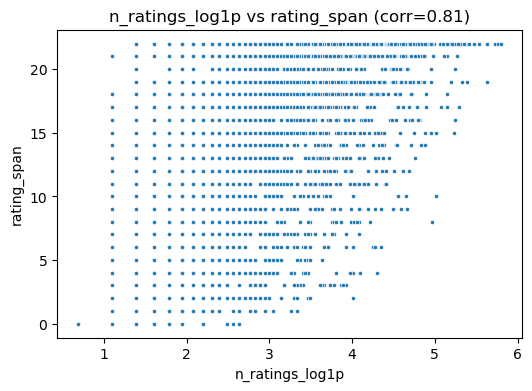

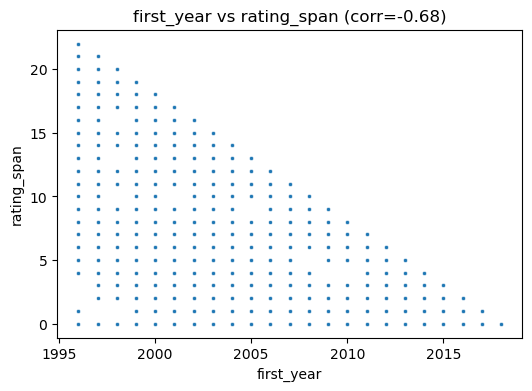

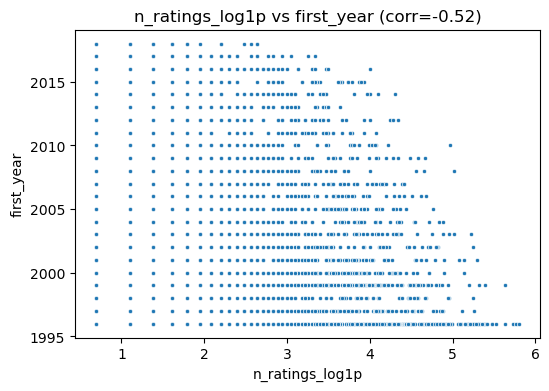

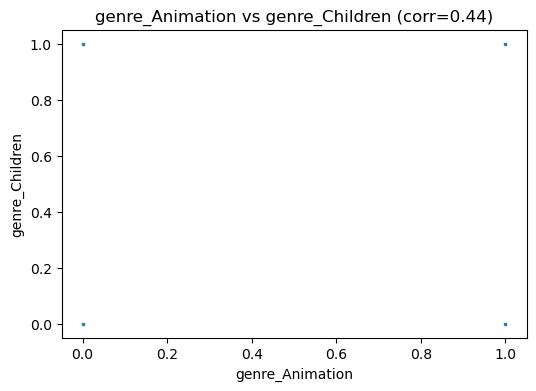

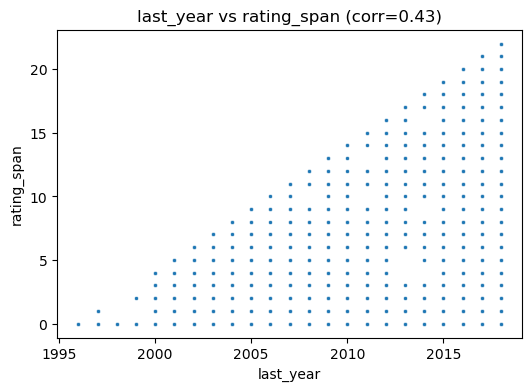

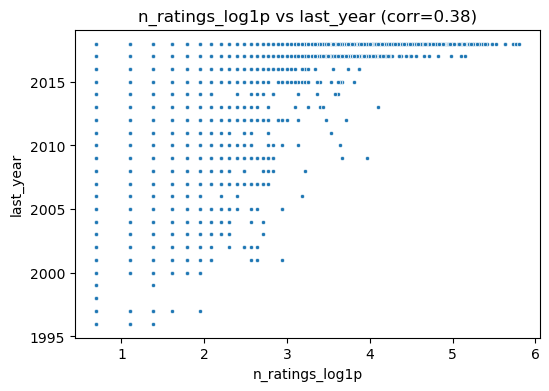

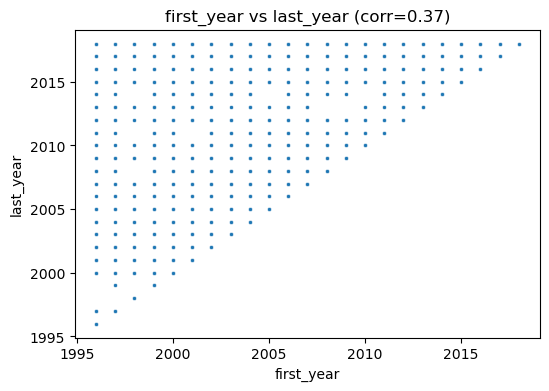

In [15]:
# now using the correlation matrix, find all couples of features that have correlation above abs (threshold), and print them in a readable format (feature1, feature2, correlation_value)
threshold = 0.3
correlated_pairs = []
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[1]):
        corr_value = corr_matrix.iat[i, j]
        if abs(corr_value) > threshold:
            feature1 = corr_matrix.index[i]
            feature2 = corr_matrix.columns[j]
            correlated_pairs.append((feature1, feature2, corr_value))

# sort the correlated pairs by absolute correlation value, descending
correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# print the correlated pairs in a readable format
for feature1, feature2, corr_value in correlated_pairs:
    print(f"{feature1} & {feature2}: {corr_value:.2f}") 

# plot a scatter plot of the all pairs
for feature1, feature2, corr_value in correlated_pairs:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X[feature1], y=X[feature2], marker=".")
    plt.title(f"{feature1} vs {feature2} (corr={corr_value:.2f})")
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.show()
        

<div style="background-color: black; padding: 20px;">
<b>Question:</b> <br>
What do you think? <br>
Are there any meaningful correlations? <br>
Is there a better way to visualize the relations between Boolean variables?
</div>